# Lab 04-2 - Transformations, Scaling, and Pipelines

In [32]:
## Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

# Let's turn off the FutureWarning messages that are generated by some of the sklearn functions we will be using. 
# These warnings are not relevant to our work and can be safely ignored.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  

The lab's examples will use data scraped from the Johnson County assessor between 2005 and 2008. These data were originally used by a University of Iowa faculty member to evaluate whether newly listed homes had a list price below what they should be valued based upon their attributes, thereby representing a good deal.

In [33]:
ic = pd.read_csv("../data/IowaCityHomeSales.csv")
# Print dimensions of data + a blank line for readability
print(ic.shape)
print("\n")

# Let's look at the raw data
ic.head()

(777, 19)




,sale.amount,sale.date,occupancy,style,built,bedrooms,bsmt,ac,attic,area.base,area.add,area.bsmt,area.garage1,area.garage2,area.living,area.lot,lon,lat,assessed
0,172500,1/3/2005,116 (Zero Lot Line),1 Story Frame,1993,3,Full,Yes,NaN,1102,0,925,418,0,1102,5520,-91.509129,41.651160,173040
1,90000,1/5/2005,113 (Condominium),1 Story Frame,2001,2,NaN,Yes,NaN,878,0,0,0,264,878,3718,-91.522964,41.673240,89470
2,168500,1/12/2005,101 (Single-Family / Owner Occupied),Split Foyer Frame,1976,4,Full,Yes,NaN,1236,0,700,576,0,1236,8800,-91.482311,41.658488,164230
3,205000,1/14/2005,101 (Single-Family / Owner Occupied),Split Foyer Frame,1995,3,Full,Yes,NaN,1466,0,500,0,0,1466,16720,-91.552236,41.648996,211890
4,121000,1/24/2005,113 (Condominium),1 Story Condo,2001,2,NaN,Yes,NaN,1150,0,0,0,528,1150,3427,-91.578144,41.652630,115430


In [34]:
# Print info about all 19 variables. Notice that
# - for many variables the number of non-null values is less than the total number of rows n=777 in the dataset. 
# This means that there are missing values in the dataset.
# - which varialbes are integers, floats, and objects (strings)
print(ic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sale.amount   777 non-null    int64  
 1   sale.date     777 non-null    object 
 2   occupancy     777 non-null    object 
 3   style         777 non-null    object 
 4   built         777 non-null    int64  
 5   bedrooms      777 non-null    int64  
 6   bsmt          598 non-null    object 
 7   ac            777 non-null    object 
 8   attic         54 non-null     object 
 9   area.base     777 non-null    int64  
 10  area.add      777 non-null    int64  
 11  area.bsmt     777 non-null    int64  
 12  area.garage1  777 non-null    int64  
 13  area.garage2  777 non-null    int64  
 14  area.living   777 non-null    int64  
 15  area.lot      777 non-null    int64  
 16  lon           777 non-null    float64
 17  lat           777 non-null    float64
 18  assessed      777 non-null    

## Training vs. Testing

In order to prevent [information leakage](https://en.wikipedia.org/wiki/Leakage_(machine_learning)) between the training and testing, it is important to split off a subset of data to be used for validation as soon as possible.  All data exploration (visualization, descriptive stats, etc.), preprocessing (rescaling, transformation, dimension reduction, etc.), and modeling (model choice, hyperparameter tuning, etc.) should be done using *only the training data*.

To create separate training and testing data sets, we'll use the `train_test_split()` function from the `model_selection` module of `sklearn`. The code below:

1. Reserves a randomly chosen subset containing 20% of the available data for the test set, sometimes called the validation set
1. Uses the argument `random_state=7` to set randomization seed that ensures the same random split will occur each time this code is run, thereby allowing replicable randomness. i.e. to work with the same validation data set. The choice of seed value `7` is completely arbitrary. If you use a different seed, you'll get a different random training/testing split. 

In [35]:
from sklearn.model_selection import train_test_split

# Pay close attention to the arguments i.e. the inputs
train, test = train_test_split(ic, test_size=0.2, random_state=7)

# 80% of n=777 is ~621
print(train.shape)
# 20% of n=777 is ~156
print(test.shape)

(621, 19)
(156, 19)


We'll now create objects `train_X`, `train_y`, `test_X`, `test_y` such that `train_y` and `test_y` contain the outcome variable `'sale.amount'` and `train_X` and `test_X` contain all numeric predictors from the training and testing data (respectively).

In [36]:
# Pull out the outcome variable sale.amount
train_y = train['sale.amount']

# Pull out only the numerical predictor variables using the .select_dtypes() method. This will return a 
# dataframe with only the numerical variables.
# We will use this to create our train_x and test_x dataframes.
# We then drop the outcome variable sale.amount from these dataframes using the .drop() method. 
# Recall that axis=0 is for rows and axis=1 is for columns.
train_x = train.select_dtypes(include=['number']).drop('sale.amount', axis=1)

# Inspect the outcome variables for training
print(train_y.head(n=2))


534    248000
629    167900
Name: sale.amount, dtype: int64


In [37]:
# Inspect the predictor variables for training
print(train_x.head(n=2))

     built  bedrooms  area.base  area.add  area.bsmt  area.garage1  \
534   1924         4        728       215        550             0   
629   2005         3        819         0        244             0   

     area.garage2  area.living  area.lot        lon        lat  assessed  
534           768         1686      8345 -91.549255  41.652618    214030  
629             0         1638      4423 -91.469109  41.657530    162570  


**Question 1**: Repeat the above to create `test_X` and `test_y`. While this may seem like a brain-dead exercise, take this opportunity to really understand each step of the process

In [38]:
# Q1: 
test_y = test['sale.amount']
print(test_y.head(2))


749    255000
414    198000
Name: sale.amount, dtype: int64


In [39]:
test_x = test.select_dtypes(include = ['number']).drop(['sale.amount'],axis = 1)
print(test_x.head(2))

     built  bedrooms  area.base  area.add  area.bsmt  area.garage1  \
749   1992         4       1582         0       1100           711   
414   1998         3        589        36        120             0   

     area.garage2  area.living  area.lot        lon        lat  assessed  
749             0         1582     15060 -91.600669  41.644513    237230  
414             0         1214      1820 -91.491018  41.646357    173530  


## Data Preparation

Now that we've got a separate validation set, we're free to explore the training data and make any modeling choices that we deem appropriate. 

### Exploratory Data Analysis (EDA)
A good first step is to perform an exploratory data analysis of the numeric predictors using data visualizations and descriptive statistics. Some code to do this is given below:

       sale.amount    built  bedrooms  area.base  area.add  area.bsmt  \
count       621.00   621.00    621.00     621.00     621.0     621.00   
mean     180461.84  1971.29      3.03     997.39      76.4     348.73   
std       90454.26    32.01      0.99     359.99     163.2     392.64   
min       38250.00  1873.00      1.00     240.00       0.0       0.00   
25%      130000.00  1957.00      2.00     729.00       0.0       0.00   
50%      157000.00  1979.00      3.00     947.00       0.0     250.00   
75%      207500.00  1998.00      4.00    1200.00      32.0     600.00   
max      815000.00  2007.00      7.00    3440.00    1192.0    2500.00   

       area.garage1  area.garage2  area.living   area.lot     lon     lat  \
count        621.00        621.00       621.00     621.00  621.00  621.00   
mean         210.34         79.14      1349.80    8937.50  -91.52   41.65   
std          251.58        162.96       508.53    8966.54    0.03    0.01   
min            0.00          0.00 

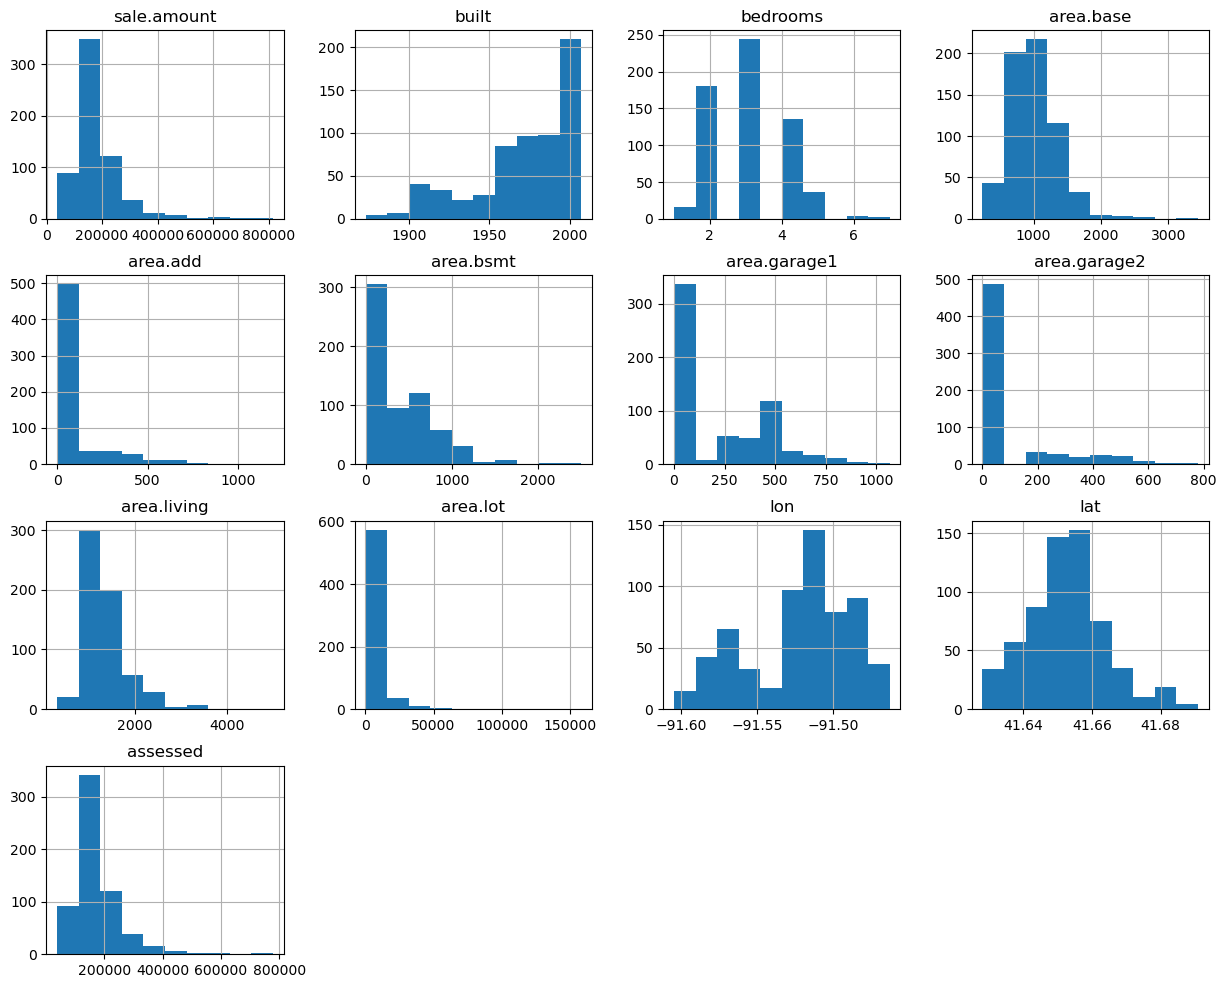

In [40]:
## Descriptive stats using .describe(), then .round()
print(train.describe().round(2))

## Distributions
train.hist(figsize = (15,12))
plt.show()

### 1. Transformations

Nothing looks too out of the ordinary in the histogram, but we might notice that some predictors, notably `'area.lot'` are extremely right-skewed with some large outliers. We might consider applying a normalizing transformation to this predictor. This code demonstrates a Box-Cox transformation using `PowerTransformer()`. You should note that the example uses the `fit()` method to fit the transformation to the provided data, which amounts to determining and storing the parameters of the transformation. Next, the `transform()` method is used to apply these parameters to actually transform the input data.

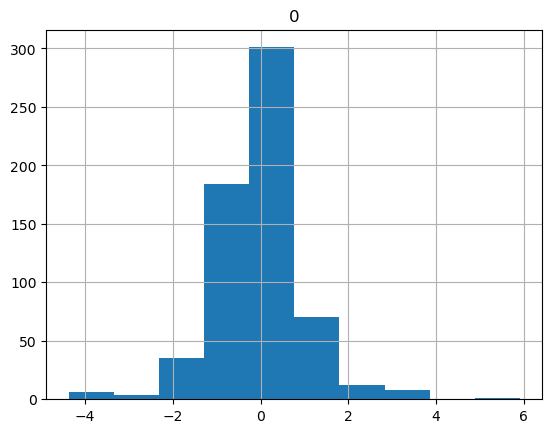

In [41]:
## Import PowerTransformer
from sklearn.preprocessing import PowerTransformer

## Box-Cox transformation. Notice the .fit() and .transform() methods. The .fit() method is used to learn 
# the parameters of the transformation from the training data, 
# and the .transform() method is used to apply the transformation to the training data.
bc_trans = PowerTransformer(method = 'box-cox').fit(train[['area.lot']])
bc_trans_arealot = bc_trans.transform(train[['area.lot']])

## Histogram of area.lot after transformation
pd.DataFrame(bc_trans_arealot).hist()
plt.show()

If the histogram shown above was all that we desired, we could have used the `fit_transform()` method, which combines the two steps. However, when applying our final machine learning approach to new data we do it separately with `.fit()` and `.transform()` since we'll want to be able to fit the transformation on the training data, then apply it later to the test data.

**Question 2**: Consider the use of a Box-Cox transformation as part of a machine learning approach. Identify and briefly explain the problem that arises in the following scenario: We apply the transformation using `fit_transform()` to the entire data set before performing the training and testing split. *Hint*: Think about information leakage.

**Answers to Question 2**: 

When you call fit_transform on the whole dataset, the Box-cox transformation uses all the data(including the test observations) to estimate how to make the distribution as close to normal as possible.The test data therefore influences the model formation which renders the model biased or fitted to the test data. 

### 2. Scaling

Based upon our initial data exploration, you should also have noticed that our predictors exist on very different scales. Thus, we must rescale them to ensure the variables with larger units do not dominate.

Each of the rescaling approaches discussed in our lecture slides are briefly demonstrated below on a few of the available predictors:

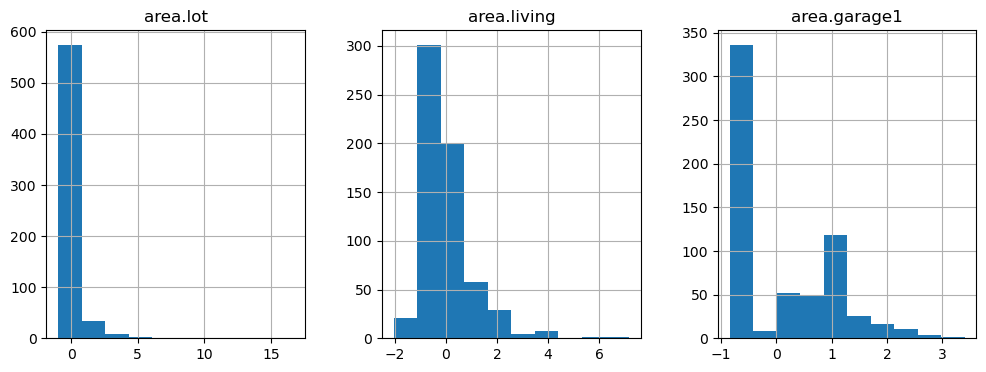

In [42]:
## A few predictors to show
example_pred_vars = ['area.lot', 'area.living', 'area.garage1']

## Ex 1: Standard Scaling (Z-scores)
# Import necessary function from library:
from sklearn.preprocessing import StandardScaler

# Compute the parameters of the transformation (here the mean and sd needed for Z-scores):
ss_trans = StandardScaler().fit(train[example_pred_vars])

# Apply the transformation to the training data:
ss_trans_out = ss_trans.transform(train[example_pred_vars])

# Visualize: 
pd.DataFrame(ss_trans_out, columns = example_pred_vars).hist(layout = (1,3), figsize = (12,4))
plt.show()

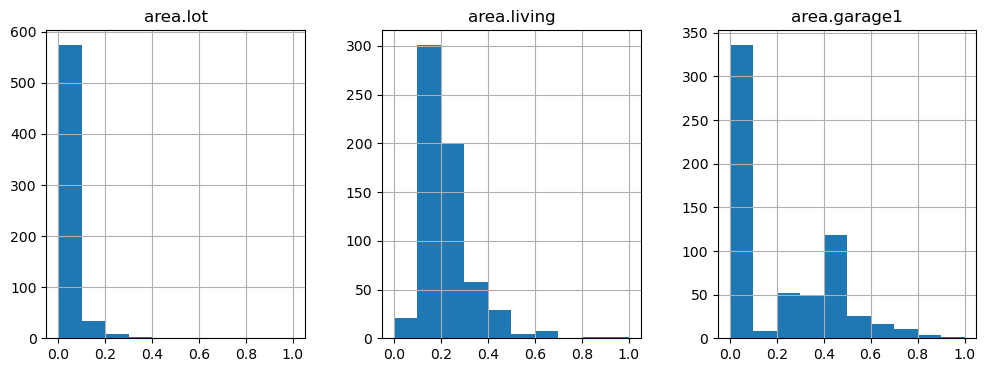

In [43]:
## Ex 2: Min-Max Scaling
# Import necessary function from library:
from sklearn.preprocessing import MinMaxScaler

# Compute the parameters of the transformation (here smallest and largest value):
rs_trans = MinMaxScaler().fit(train[example_pred_vars])

# Apply the transformation to the training data:
rs_trans_out = rs_trans.transform(train[example_pred_vars])

# Visualize: 
pd.DataFrame(rs_trans_out, columns = example_pred_vars).hist(layout = (1,3), figsize = (12,4))
plt.show()

Two more standardization functions to know about that aren't shown: robust scaling and max absolute scaling

In [44]:
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler

### 3. Pipelines

One of the most attractive features of `sklearn` are **pipelines**, or sequences of data handling steps that can easily be applied to a variety of machine learning tasks such as training, validation, hyperparameter tuning and more. These are especially useful when running the same set of tasks over and over again. 

The example below demonstrates a simple pipeline that applies a Box-Cox transformation followed by min-max rescaling:

<class 'numpy.ndarray'>


(621, 3)




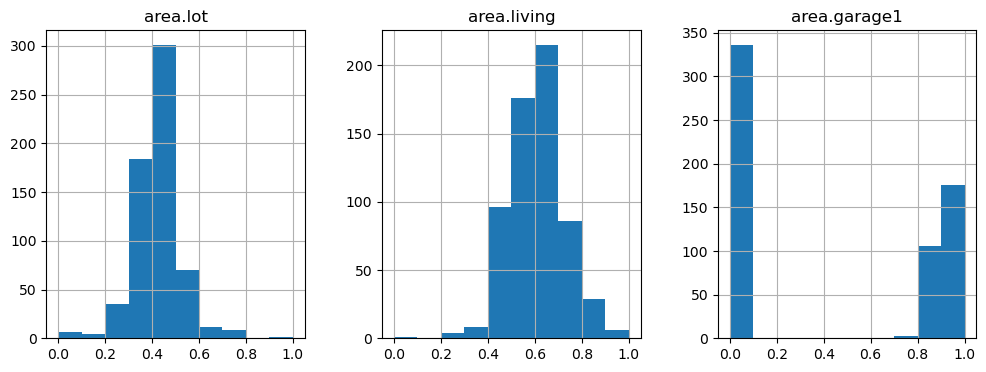

In [45]:
# THIS IS AN IMPORTANT CODE BLOCK, MAKE SURE YOU SPEND TIME TO UNDERSTAND IT SINCE 
# WE'LL BE USING PIPELINES OFTEN
from sklearn.pipeline import Pipeline 

## Set up the two steps of the pipeline: the transformation and the rescaling
my_pipeline = Pipeline([
    ('transformer', PowerTransformer(method = 'yeo-johnson')),
    ('scaler', MinMaxScaler())
])

## .fit() the pipeline to the subset of 3 variables we visualized earlier in the histograms above,
## and then .transform() the training data using the fitted pipeline
fitted_pipe = my_pipeline.fit(train[example_pred_vars])
train_transformed = fitted_pipe.transform(train[example_pred_vars])

## The output of the pipeline is a numpy array with 621 rows and 3 columns
print(type(train_transformed))
print("\n")
print(train_transformed.shape)
print("\n")

## So we convert the transformed data to a DataFrame
train_transformed = pd.DataFrame(
    data = train_transformed, 
    columns = example_pred_vars
)

# Visualize the transformed data
train_transformed.hist(layout = (1,3), figsize = (12,4))
plt.show()

While they are not consequential in this simple example, we should notice that the pipeline's steps are named `'transformer`' and `'scaler'`. These are names that we choose and can subsequently use to refer to certain steps within the pipeline as we see fit e.g. `'transformation`' and `'scaling'`

Later we'll add a $k$-nearest neighbors model to this pipeline.

## Application

To conclude this lab, you will apply the workflow from the example to a new dataset on your own. The data is from a database on breast cancer in Wisconsin. The data was obtained from the UC-Irvine machine learning repository, you can read more about these data [at this link](https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)).

Each observation consists of the mean values for various cell characteristics of a patient. The goal is to predict the patient's breast cancer diagnosis, recorded as "Label" which is binary. Thus is a classification problem:
* `M` for malignant (cancerous)
* `B` for benign (non-cancerous)

In [46]:
## Read data
wbc = pd.read_csv("../data/wisc_bc.csv")

print(wbc.shape)
print("\n")

wbc.head()

(569, 12)




,ID,Label,Radius,Texture,Perimeter,Area,Smoothness,Compactness,Concavity,Concave,Symmetry,Fractal
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883


**Question 3**:
    
- **Part A**: Create a 70% training, 30% testing data split using random_state = 5. Consider naming this `train_wbc` and `test_wbc` so you don't overwrite the original `train` and `test` dataframes.
- **Part B**: Create histograms showing the distributions of the 10 numeric predictors, then decide upon whether a data preparation pipeline should include transformations, rescaling, or both.
- **Part C**: Set up a machine learning pipeline that includes the following steps:
    1. A normalizing transformation 
    2. Rescaling
- **Part D**: After you `.fit()` your pipeline, apply it to the training data and convert it to pandas data frame format
- **Part E**: Compare a histogram of the transformed and rescaled variables to the histogram Part B. Was your pipeline successful?

In [ ]:
# Q3.a)
train_wbc,test_wbc = train_test_split(wbc,test_size =0.3, random_state = 5)
print(train_wbc)
print(test_wbc.shape)

In [ ]:
print(train.describe().round(2))

## Distributions
train.hist(figsize = (15,12))
plt.show()

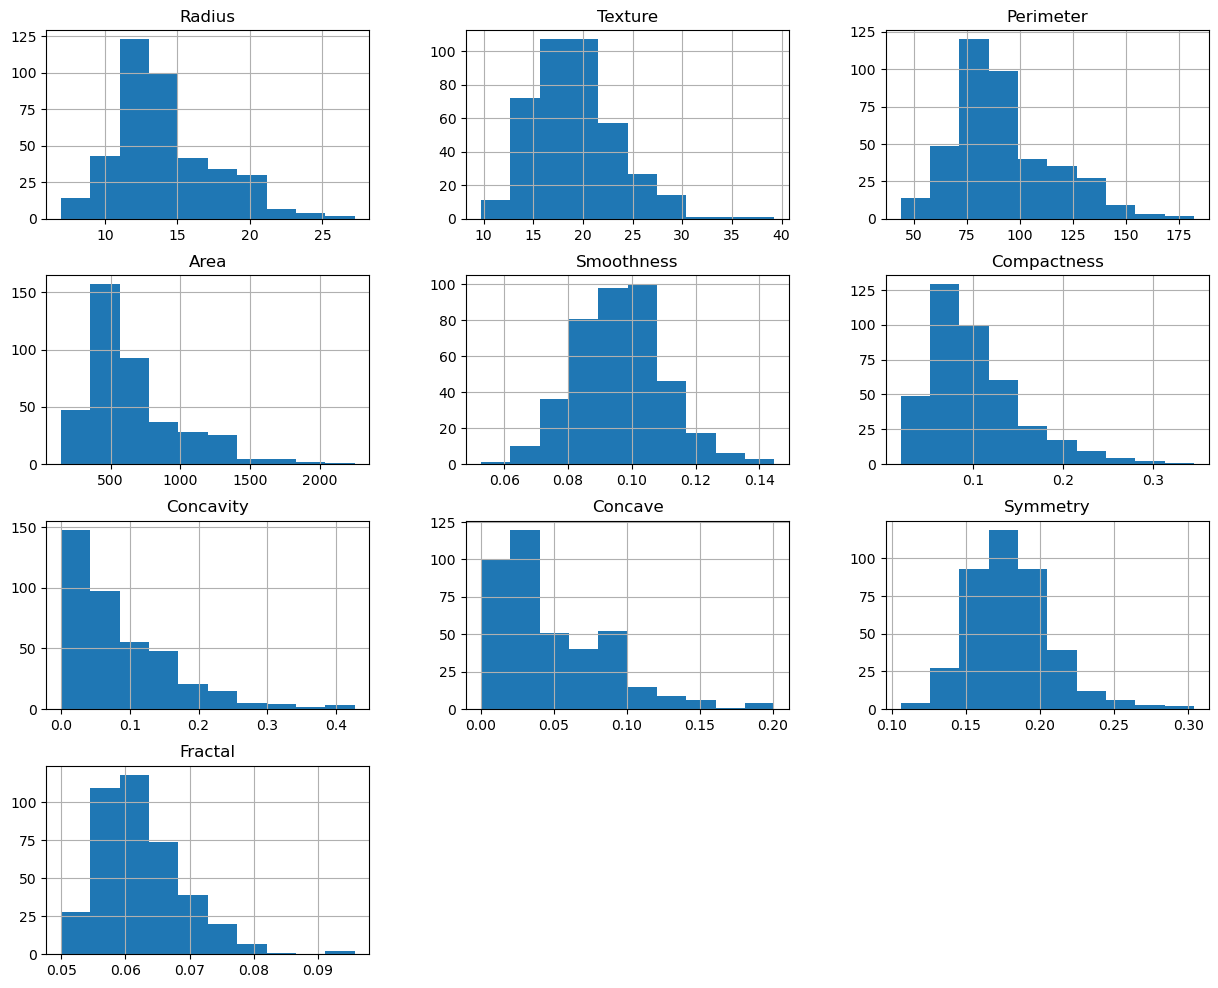

In [60]:
# Q3.b)
train_wbc_num = train_wbc.select_dtypes(include = ['number']).drop('ID', axis =1)
train_wbc_num.hist(figsize =(15,12))
plt.show()

In [ ]:
# Q3.c) 
pred_vars =['Area','Concavity','Perimeter']
pipeline_new = Pipeline([
    ('transformation', PowerTransformer(method = 'yeo-johnson')),
    ('scaler', MinMaxScaler())
])

fitted_pipeline = pipeline_new.fit(train_wbc[pred_vars])
train_wbc_transformed = fitted_pipeline.transform(train_wbc[pred_vars])
print(type(train_transformed))
print("\n")
print(train_transformed.shape)
print("\n")



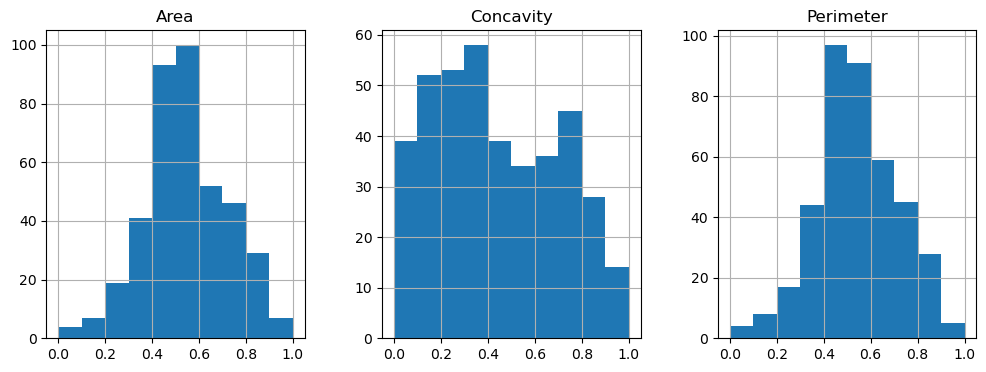

In [68]:
# Q3.d)
train_wbc_transformed = pd.DataFrame(
    data = train_wbc_transformed,
    columns = pred_vars
)

train_wbc_transformed.hist(layout = (1,3), figsize = (12,4))
plt.show()


Yes it was successful in transforming the data. Area, Concavity and Perimeter all show more normal distributions after the transformation. Area also had a lot of outliers in the histogram from B which was reduced after the rescaling.